In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [2]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.RandomCrop(32,padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914,0.4822,0.4465),
        (0.2023,0.1994,0.2010)
    )
])

trainset=CIFAR10(root="./data",train=True,download=True,transform=transform)
testset=CIFAR10(root="./data",train=False,download=True,transform=transform)

In [3]:
trainloader=DataLoader(trainset,batch_size=128,shuffle=True)
testloader=DataLoader(testset,batch_size=128)

### Building the CNN

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv_layers=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),#kernel size=2 and stride=2

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),#kernel size=2 and stride=2

            nn.Conv2d(64,128,kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),#kernel size=2 and stride=2

            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(2*2*256,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x=self.conv_layers(x)
        x=x.view(x.size(0),-1)#flattening
        x=self.fc_layers(x)

        return x
         

In [9]:
model=CNN()

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training the CNN

In [11]:
epochs = 50
for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output=model.forward(images)#FP
        loss=criterion(output,labels)#loss func
        loss.backward()#BP
        optimizer.step() 

        epoch_training_loss +=loss.item()
    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")


epoch=1/50 & loss=1.3971303518470901
epoch=2/50 & loss=1.0287016872554788
epoch=3/50 & loss=0.8942883883595771
epoch=4/50 & loss=0.8110567102651767
epoch=5/50 & loss=0.7596637232376792
epoch=6/50 & loss=0.7143976987170442
epoch=7/50 & loss=0.6810457187387949
epoch=8/50 & loss=0.6470298783858414
epoch=9/50 & loss=0.6213281229328926
epoch=10/50 & loss=0.6035254909406842
epoch=11/50 & loss=0.5783013016976359
epoch=12/50 & loss=0.5701555853609539
epoch=13/50 & loss=0.5474254415010857
epoch=14/50 & loss=0.5331479416174048
epoch=15/50 & loss=0.5152258304378871
epoch=16/50 & loss=0.5064993176771246
epoch=17/50 & loss=0.49633685745241696
epoch=18/50 & loss=0.4866770776488897
epoch=19/50 & loss=0.4760306480595523
epoch=20/50 & loss=0.4661918829011795
epoch=21/50 & loss=0.45839012698139375
epoch=22/50 & loss=0.4500434021358295
epoch=23/50 & loss=0.43490759064169493
epoch=24/50 & loss=0.42871740338442577
epoch=25/50 & loss=0.4158264360845546
epoch=26/50 & loss=0.41197369977488846
epoch=27/50 & lo

### Evaluating our CNN

In [12]:
model.eval()

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Final Test Accuracy: {accuracy:.2f}%")

Final Test Accuracy: 82.59%


### Confusion Matrix 

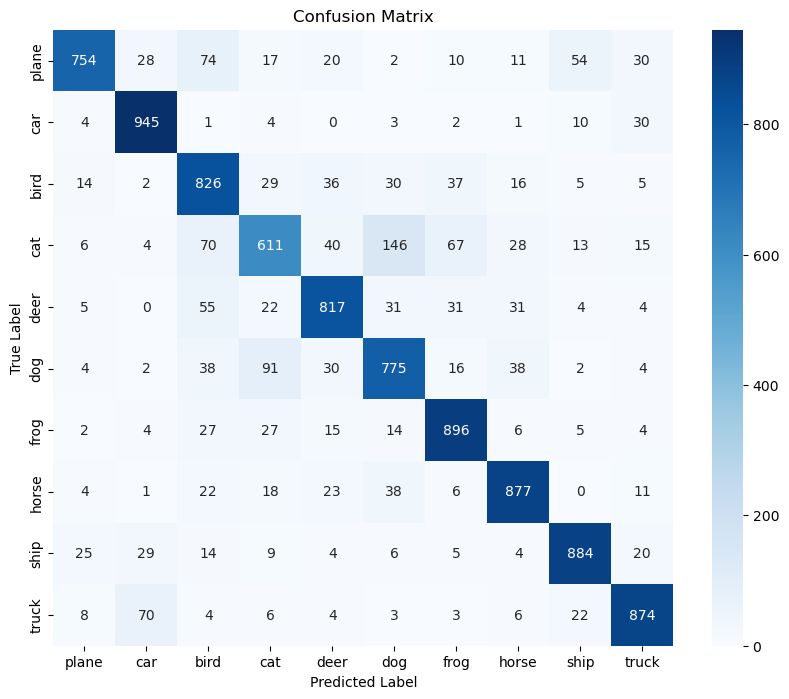

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Per Class Accuracy

In [14]:
import numpy as np

class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

with torch.no_grad():

    for images, labels in testloader:

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        c = (predicted == labels).squeeze()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

for i in range(10):
    print(f"{classes[i]} accuracy: {100 * class_correct[i] / class_total[i]:.2f}%")

plane accuracy: 75.00%
car accuracy: 93.70%
bird accuracy: 82.90%
cat accuracy: 60.90%
deer accuracy: 79.50%
dog accuracy: 76.20%
frog accuracy: 90.40%
horse accuracy: 87.50%
ship accuracy: 89.70%
truck accuracy: 87.80%


### Real Image Prediction

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5400686..1.6817627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.8671105].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.56914604..1.5354356].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.1940055].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.7983952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.6213496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6

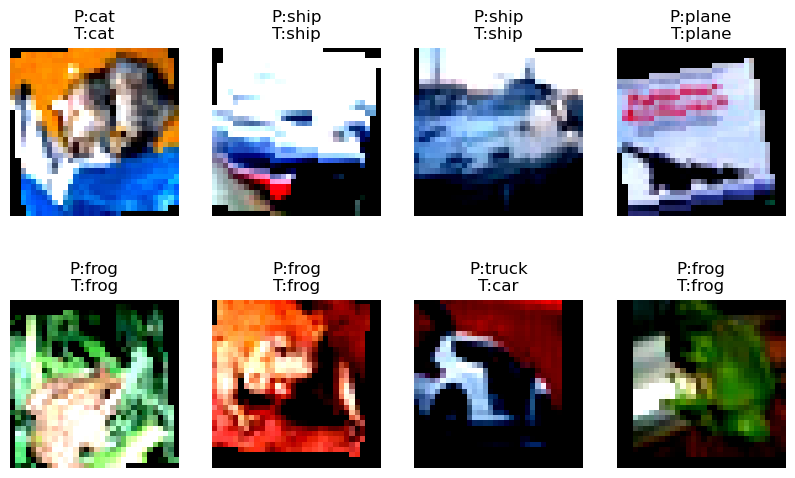

In [15]:
import numpy as np
import matplotlib.pyplot as plt

dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = model(images)

_, predicted = torch.max(outputs,1)

fig = plt.figure(figsize=(10,6))

for i in range(8):

    ax = fig.add_subplot(2,4,i+1)

    img = images[i] / 2 + 0.5
    npimg = img.numpy()

    plt.imshow(np.transpose(npimg,(1,2,0)))

    ax.set_title(f"P:{classes[predicted[i]]}\nT:{classes[labels[i]]}")

    plt.axis("off")

plt.show()

### Prediction Confidence

In [16]:
import torch.nn.functional as F

outputs = model(images)

probs = F.softmax(outputs, dim=1)

for i in range(5):

    print("Image", i)

    for j in range(10):
        print(f"{classes[j]}: {probs[i][j]*100:.2f}%")

    print()

Image 0
plane: 0.01%
car: 0.05%
bird: 0.03%
cat: 88.49%
deer: 0.00%
dog: 4.69%
frog: 6.70%
horse: 0.01%
ship: 0.00%
truck: 0.03%

Image 1
plane: 0.09%
car: 29.75%
bird: 0.00%
cat: 0.00%
deer: 0.00%
dog: 0.00%
frog: 0.00%
horse: 0.00%
ship: 67.94%
truck: 2.23%

Image 2
plane: 4.43%
car: 4.21%
bird: 0.27%
cat: 0.00%
deer: 0.01%
dog: 0.00%
frog: 0.00%
horse: 0.00%
ship: 90.47%
truck: 0.62%

Image 3
plane: 80.04%
car: 2.23%
bird: 1.19%
cat: 0.69%
deer: 0.08%
dog: 0.01%
frog: 0.00%
horse: 0.00%
ship: 7.70%
truck: 8.06%

Image 4
plane: 0.00%
car: 0.00%
bird: 0.02%
cat: 0.00%
deer: 0.05%
dog: 0.00%
frog: 99.93%
horse: 0.00%
ship: 0.00%
truck: 0.00%



### Prediction Distribution Chart

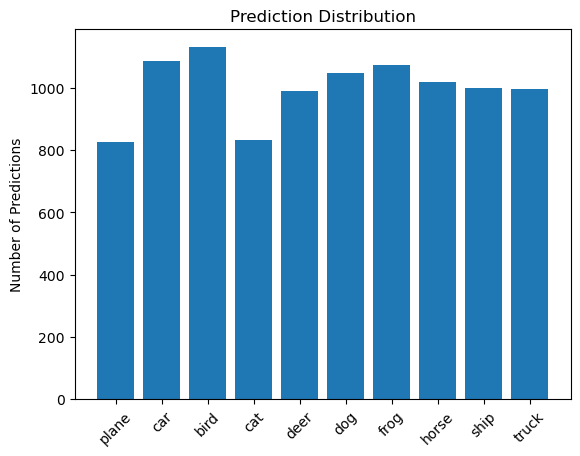

In [17]:
import matplotlib.pyplot as plt
import numpy as np

counts = np.bincount(all_preds)

plt.bar(classes, counts)

plt.xticks(rotation=45)

plt.title("Prediction Distribution")

plt.ylabel("Number of Predictions")

plt.show()

 ### Training History Graph (Loss + Accuracy)

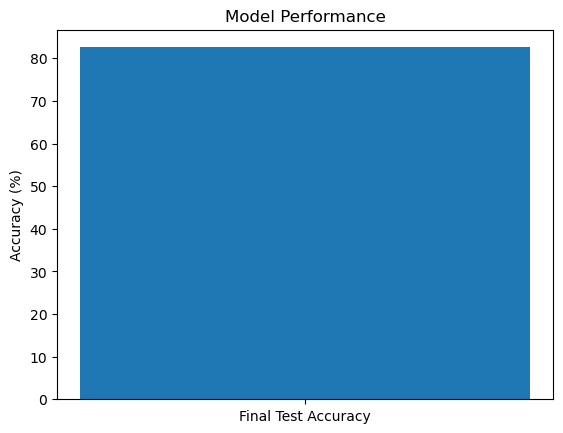

In [20]:
import matplotlib.pyplot as plt

metrics = {
    "Final Test Accuracy": accuracy
}

plt.bar(metrics.keys(), metrics.values())

plt.ylabel("Accuracy (%)")
plt.title("Model Performance")

plt.show()

### Misclassified image gallery

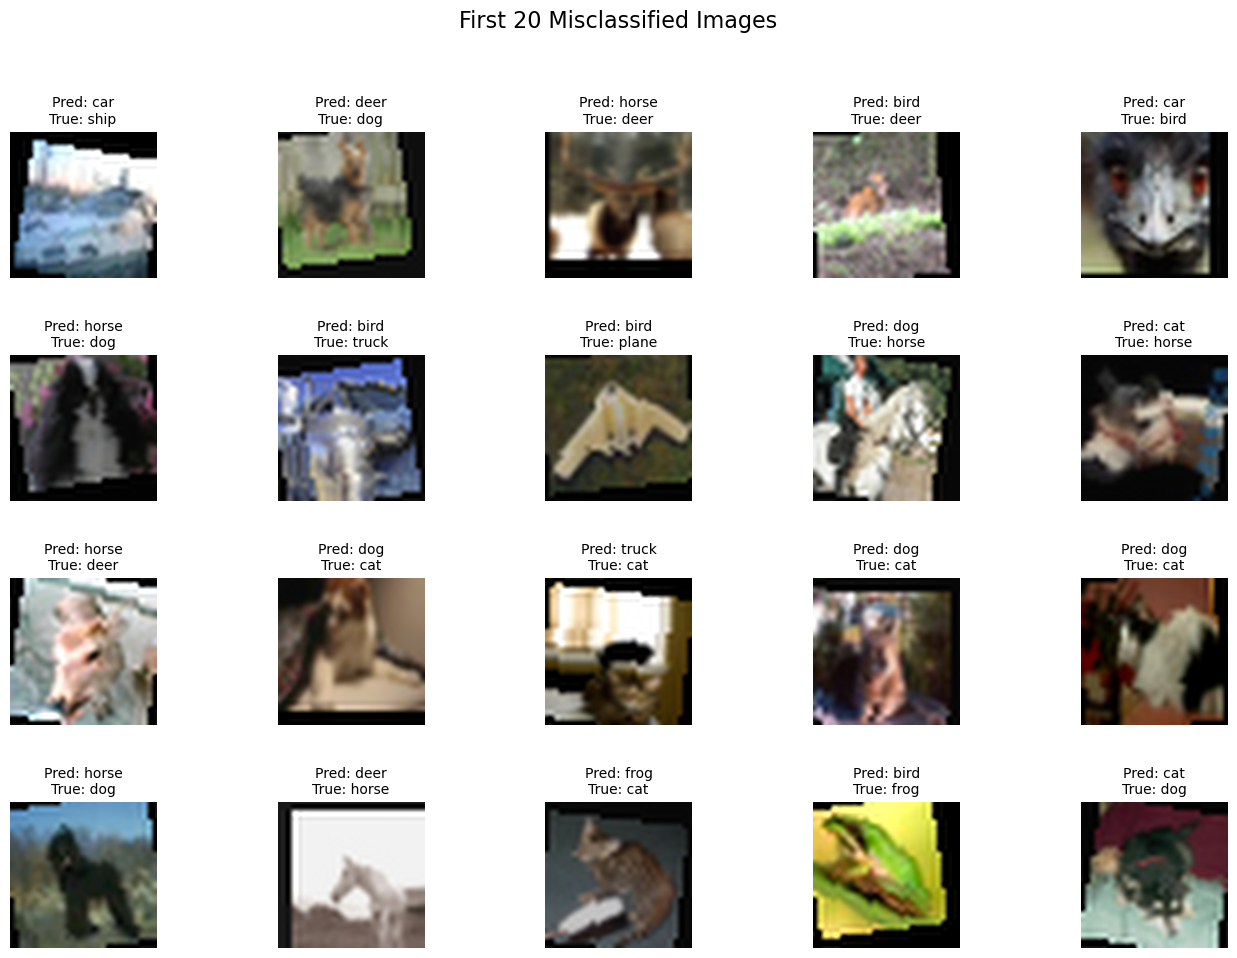

In [24]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

mis_images = []
mis_labels = []
mis_preds = []

model.eval()

with torch.no_grad():
    for images, labels in testloader:

        outputs = model(images)
        _, predicted = torch.max(outputs,1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                mis_images.append(images[i].cpu())
                mis_labels.append(labels[i].cpu())
                mis_preds.append(predicted[i].cpu())

        if len(mis_images) >= 20:
            break


# CIFAR10 normalization values (used earlier during training)
mean = np.array([0.4914, 0.4822, 0.4465])
std = np.array([0.2023, 0.1994, 0.2010])

def unnormalize(img):
    img = img.numpy().transpose((1,2,0))
    img = std * img + mean
    img = np.clip(img,0,1)
    return img


plt.figure(figsize=(14,10))

for i in range(20):

    ax = plt.subplot(4,5,i+1)

    img = unnormalize(mis_images[i])

    plt.imshow(img, interpolation="lanczos")

    ax.set_title(
        f"Pred: {classes[mis_preds[i]]}\nTrue: {classes[mis_labels[i]]}",
        fontsize=10
    )

    plt.axis("off")


plt.suptitle("First 20 Misclassified Images", fontsize=16)

plt.tight_layout(pad=3.0)

plt.show()